In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings
warnings.filterwarnings("ignore")

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [4]:
# Direct full path to database
DB_PATH = r"C:\Users\mansi\OneDrive\Desktop\churn-prediction-system\churn_data.db"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM customers", conn)
conn.close()

print("✅ Data loaded from SQLite database")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\nColumn Names:\n{list(df.columns)}")

✅ Data loaded from SQLite database
   Rows    : 7043
   Columns : 21

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
# First 5 rows
print("📋 First 5 rows of the dataset:")
df.head()

📋 First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Dataset information
print("📊 Dataset Info:")
print(f"Shape: {df.shape}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())

📊 Dataset Info:
Shape: (7043, 21)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing Values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMov

In [7]:
# Fix TotalCharges column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Basic statistics
print("📊 Basic Statistics:")
df.describe()

📊 Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


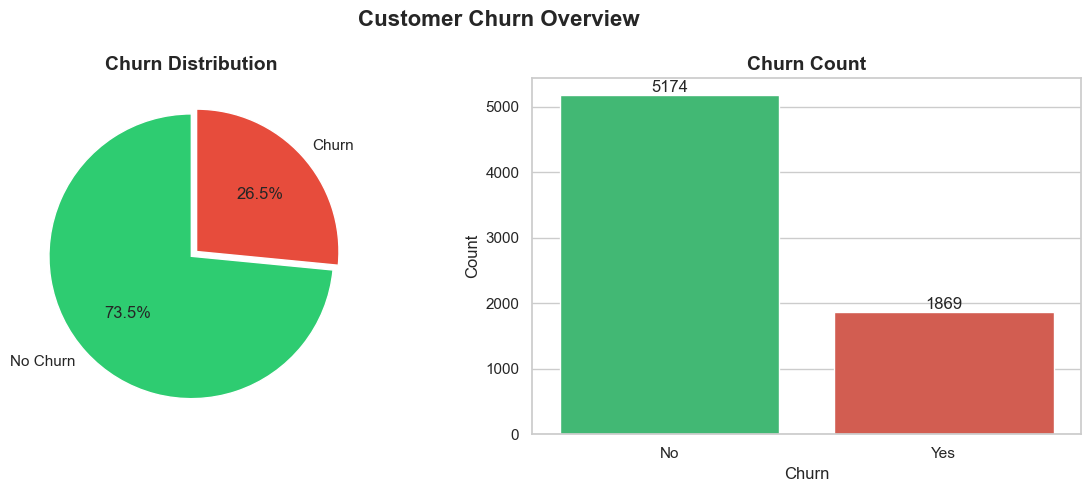

✅ Chart saved!


In [11]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
churn_counts = df["Churn"].value_counts()
axes[0].pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title("Churn Distribution", fontsize=14, fontweight="bold")

# Bar Chart
sns.countplot(data=df, x="Churn", palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Churn Count", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Count")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=12)

plt.suptitle("Customer Churn Overview", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

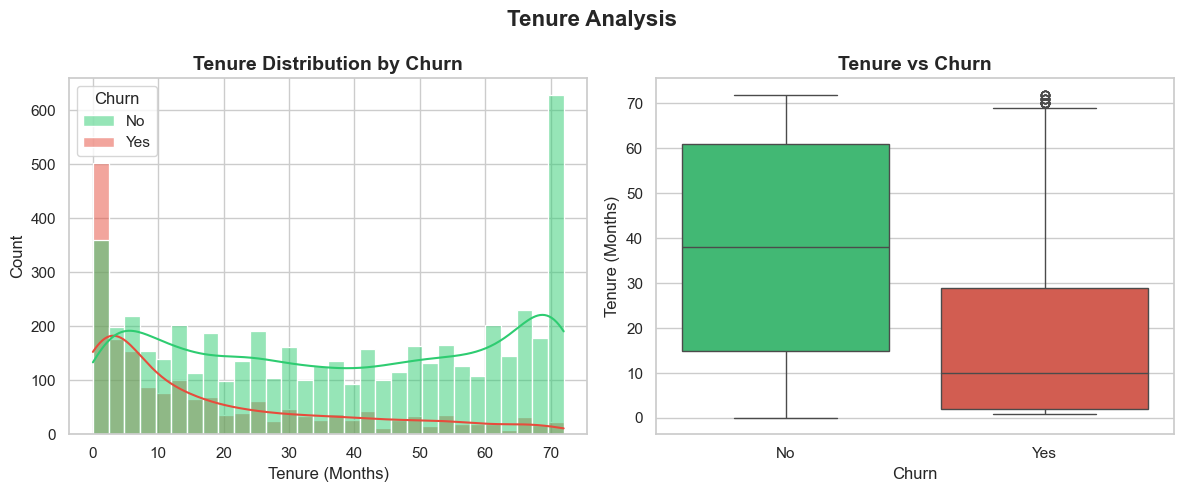

✅ Chart saved!


In [12]:
# Tenure Distribution by Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, 
             palette=["#2ecc71", "#e74c3c"], ax=axes[0], kde=True)
axes[0].set_title("Tenure Distribution by Churn", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Tenure (Months)")
axes[0].set_ylabel("Count")

# Box Plot
sns.boxplot(data=df, x="Churn", y="tenure", 
            palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Tenure vs Churn", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Tenure (Months)")

plt.suptitle("Tenure Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("tenure_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

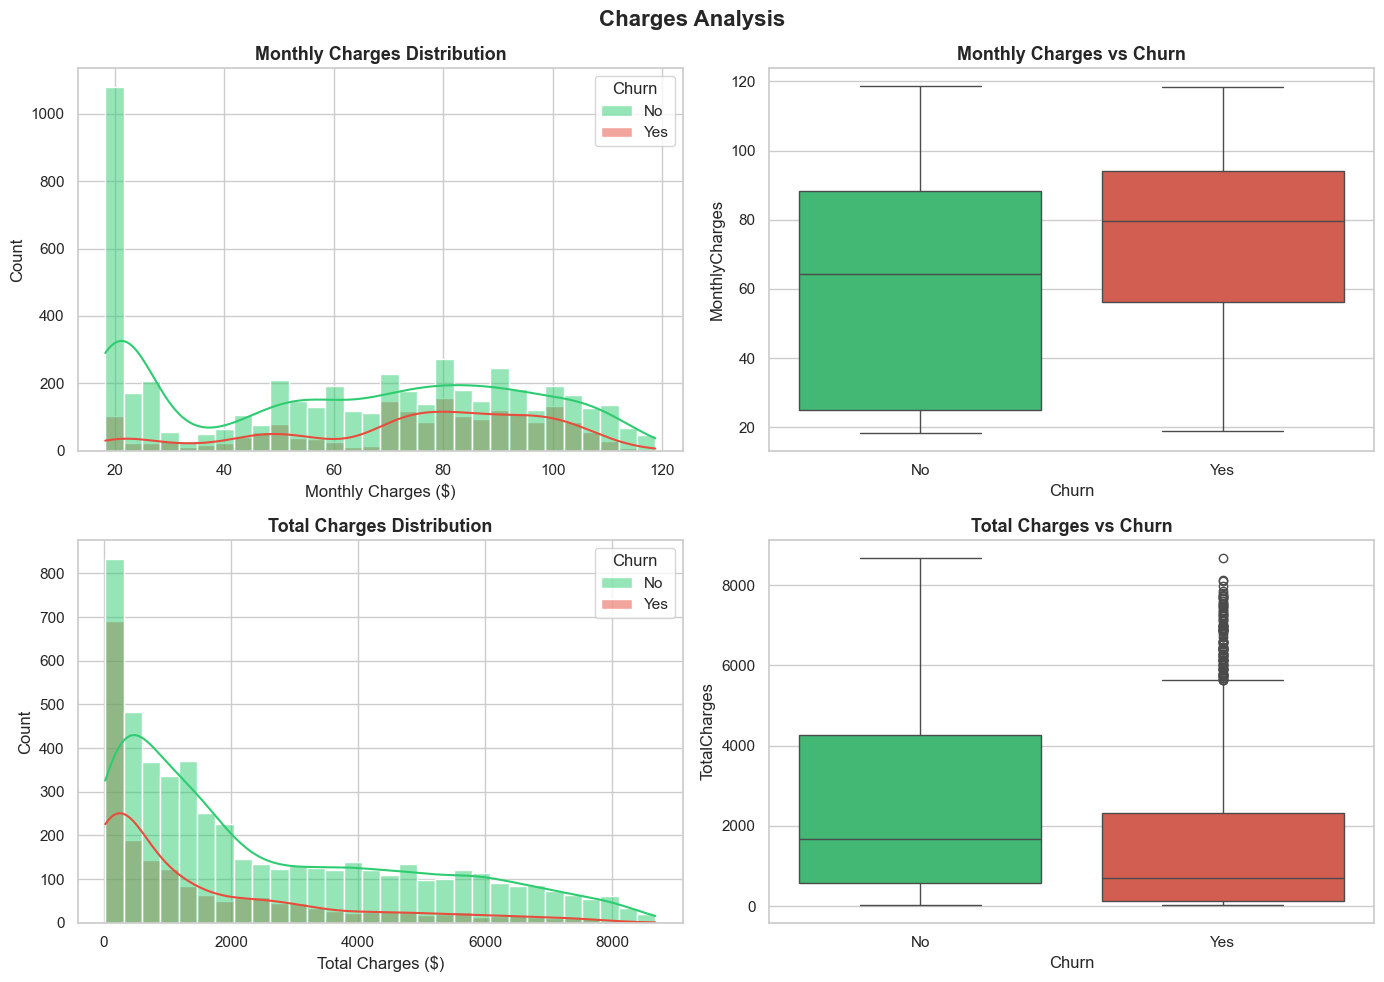

✅ Chart saved!


In [13]:
# Monthly Charges & Total Charges Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Monthly Charges Histogram
sns.histplot(data=df, x="MonthlyCharges", hue="Churn",
             bins=30, palette=["#2ecc71", "#e74c3c"], ax=axes[0][0], kde=True)
axes[0][0].set_title("Monthly Charges Distribution", fontsize=13, fontweight="bold")
axes[0][0].set_xlabel("Monthly Charges ($)")

# Monthly Charges Box Plot
sns.boxplot(data=df, x="Churn", y="MonthlyCharges",
            palette=["#2ecc71", "#e74c3c"], ax=axes[0][1])
axes[0][1].set_title("Monthly Charges vs Churn", fontsize=13, fontweight="bold")

# Total Charges Histogram
sns.histplot(data=df, x="TotalCharges", hue="Churn",
             bins=30, palette=["#2ecc71", "#e74c3c"], ax=axes[1][0], kde=True)
axes[1][0].set_title("Total Charges Distribution", fontsize=13, fontweight="bold")
axes[1][0].set_xlabel("Total Charges ($)")

# Total Charges Box Plot
sns.boxplot(data=df, x="Churn", y="TotalCharges",
            palette=["#2ecc71", "#e74c3c"], ax=axes[1][1])
axes[1][1].set_title("Total Charges vs Churn", fontsize=13, fontweight="bold")

plt.suptitle("Charges Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("charges_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

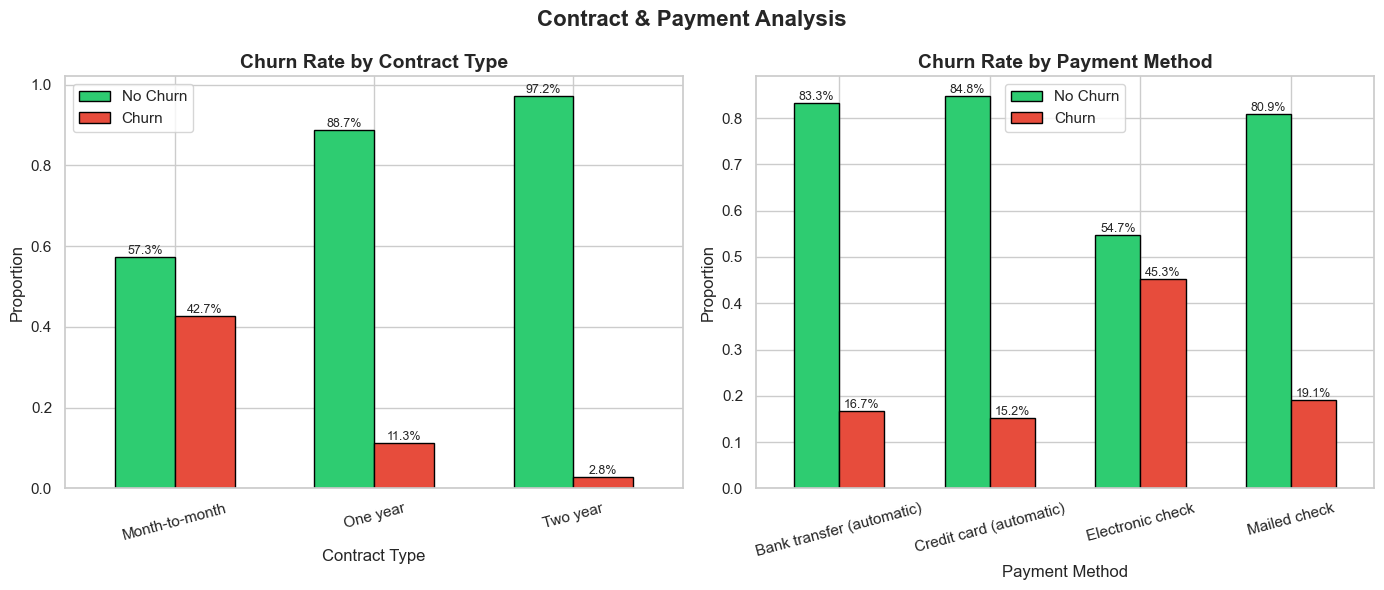

✅ Chart saved!


In [14]:
# Contract Type & Payment Method Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contract Type
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
contract_churn.plot(kind="bar", ax=axes[0], 
                    color=["#2ecc71", "#e74c3c"], 
                    edgecolor="black", width=0.6)
axes[0].set_title("Churn Rate by Contract Type", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Contract Type")
axes[0].set_ylabel("Proportion")
axes[0].legend(["No Churn", "Churn"])
axes[0].tick_params(axis="x", rotation=15)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9)

# Payment Method
payment_churn = df.groupby("PaymentMethod")["Churn"].value_counts(normalize=True).unstack()
payment_churn.plot(kind="bar", ax=axes[1],
                   color=["#2ecc71", "#e74c3c"],
                   edgecolor="black", width=0.6)
axes[1].set_title("Churn Rate by Payment Method", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Proportion")
axes[1].legend(["No Churn", "Churn"])
axes[1].tick_params(axis="x", rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=9)

plt.suptitle("Contract & Payment Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("contract_payment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

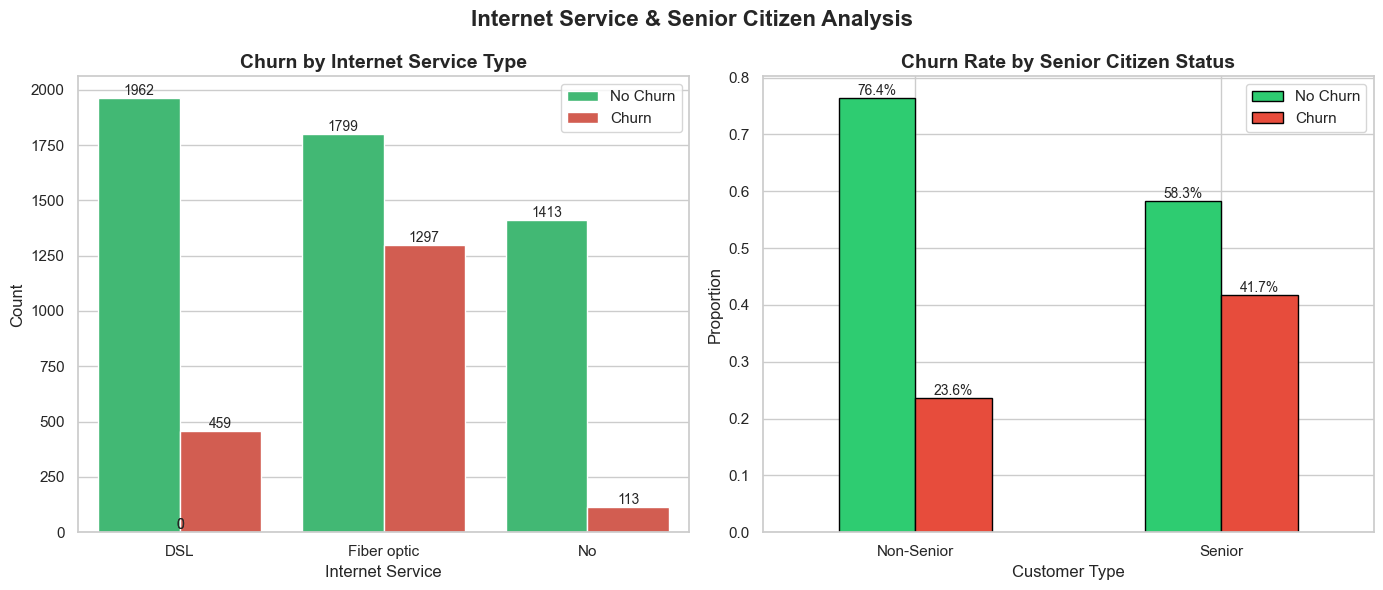

✅ Chart saved!


In [15]:
# Internet Service & Senior Citizen Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Internet Service
sns.countplot(data=df, x="InternetService", hue="Churn",
              palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Churn by Internet Service Type", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Internet Service")
axes[0].set_ylabel("Count")
axes[0].legend(["No Churn", "Churn"])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=10)

# Senior Citizen
senior_churn = df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack()
senior_churn.index = ["Non-Senior", "Senior"]
senior_churn.plot(kind="bar", ax=axes[1],
                  color=["#2ecc71", "#e74c3c"],
                  edgecolor="black", width=0.5)
axes[1].set_title("Churn Rate by Senior Citizen Status", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Customer Type")
axes[1].set_ylabel("Proportion")
axes[1].legend(["No Churn", "Churn"])
axes[1].tick_params(axis="x", rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1%}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=10)

plt.suptitle("Internet Service & Senior Citizen Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("internet_senior_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

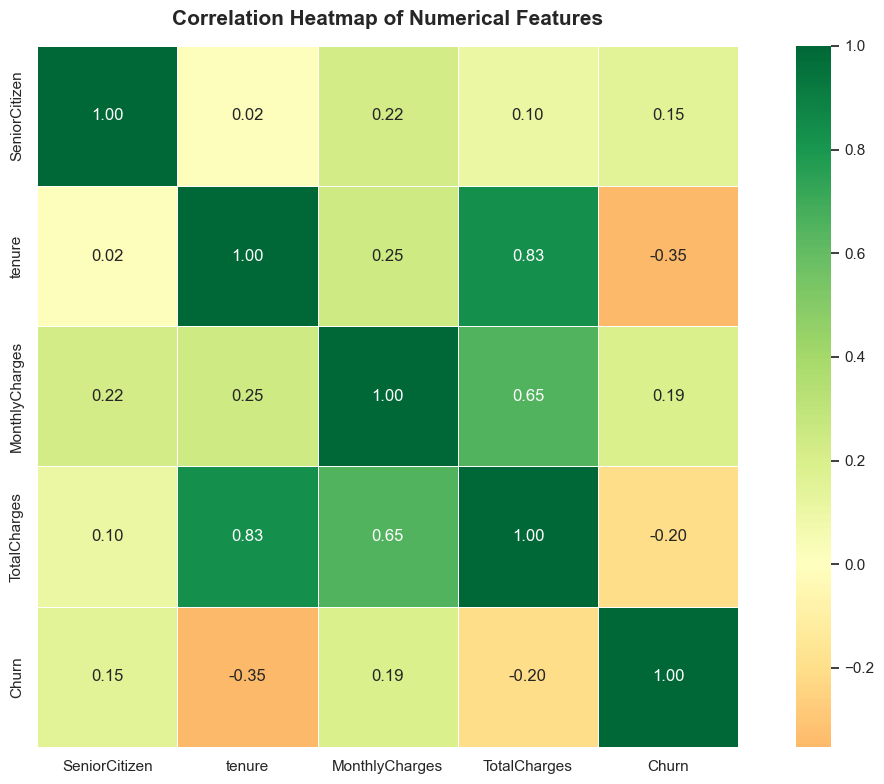

✅ Chart saved!


In [16]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Encode churn for correlation
df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})
df_corr["TotalCharges"] = pd.to_numeric(df_corr["TotalCharges"], errors="coerce")

# Select only numerical columns
num_cols = df_corr.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr_matrix = df_corr[num_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Heatmap of Numerical Features", 
             fontsize=15, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

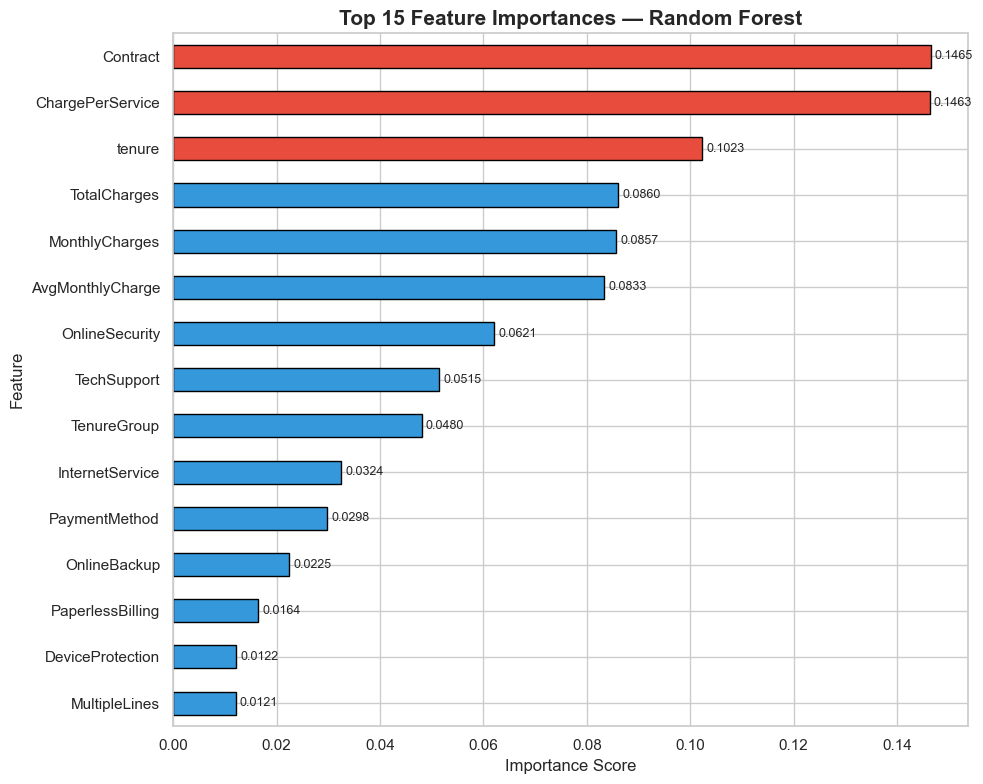

✅ Chart saved!


In [18]:
# Feature Importance from Trained Model
import joblib

ARTIFACTS_DIR = r"C:\Users\mansi\OneDrive\Desktop\churn-prediction-system\artifacts"
MODEL_PATH = os.path.join(ARTIFACTS_DIR, "churn_model.pkl")
FEATURES_PATH = os.path.join(ARTIFACTS_DIR, "feature_columns.pkl")

model = joblib.load(MODEL_PATH)
feature_columns = joblib.load(FEATURES_PATH)

# Get feature importances
importances = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=True).tail(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#e74c3c" if i >= len(importances) - 3 
          else "#3498db" for i in range(len(importances))]
importances.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.set_title("Top 15 Feature Importances — Random Forest", 
             fontsize=15, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.4f}",
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha="left", va="center", fontsize=9, 
        xytext=(3, 0), textcoords="offset points")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved!")

In [19]:
# EDA Summary Insights
print("=" * 55)
print("        EDA SUMMARY — KEY INSIGHTS")
print("=" * 55)

# 1. Churn Rate
churn_rate = (df["Churn"].value_counts()["Yes"] / len(df)) * 100
print(f"\n📊 1. Overall Churn Rate        : {churn_rate:.1f}%")
print(f"      No Churn                  : {100 - churn_rate:.1f}%")

# 2. Contract Type
print(f"\n📊 2. Churn by Contract Type:")
contract_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
)
for contract, rate in contract_churn.items():
    print(f"      {contract:25s} : {rate:.1f}%")

# 3. Tenure
avg_tenure_churn = df[df["Churn"] == "Yes"]["tenure"].mean()
avg_tenure_no_churn = df[df["Churn"] == "No"]["tenure"].mean()
print(f"\n📊 3. Average Tenure:")
print(f"      Churned Customers         : {avg_tenure_churn:.1f} months")
print(f"      Retained Customers        : {avg_tenure_no_churn:.1f} months")

# 4. Payment Method
print(f"\n📊 4. Churn by Payment Method:")
payment_churn = df.groupby("PaymentMethod")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
)
for method, rate in payment_churn.items():
    print(f"      {method:35s}: {rate:.1f}%")

# 5. Internet Service
print(f"\n📊 5. Churn by Internet Service:")
internet_churn = df.groupby("InternetService")["Churn"].apply(
    lambda x: (x == "Yes").sum() / len(x) * 100
)
for service, rate in internet_churn.items():
    print(f"      {service:25s} : {rate:.1f}%")

# 6. Senior Citizens
senior_churn = df[df["SeniorCitizen"] == 1]["Churn"].value_counts(normalize=True)["Yes"] * 100
print(f"\n📊 6. Senior Citizen Churn Rate : {senior_churn:.1f}%")

print("\n" + "=" * 55)
print("✅ EDA Complete — All insights extracted!")
print("=" * 55)

        EDA SUMMARY — KEY INSIGHTS

📊 1. Overall Churn Rate        : 26.5%
      No Churn                  : 73.5%

📊 2. Churn by Contract Type:
      Month-to-month            : 42.7%
      One year                  : 11.3%
      Two year                  : 2.8%

📊 3. Average Tenure:
      Churned Customers         : 18.0 months
      Retained Customers        : 37.6 months

📊 4. Churn by Payment Method:
      Bank transfer (automatic)          : 16.7%
      Credit card (automatic)            : 15.2%
      Electronic check                   : 45.3%
      Mailed check                       : 19.1%

📊 5. Churn by Internet Service:
      DSL                       : 19.0%
      Fiber optic               : 41.9%
      No                        : 7.4%

📊 6. Senior Citizen Churn Rate : 41.7%

✅ EDA Complete — All insights extracted!
